This notebook explores the Animals-10 dataset before training models.

**What we'll do:**
- Load and verify the dataset
- Visualize sample images
- Check class distribution
- Verify stratified splits
- Calculate image statistics

In [1]:
import sys
sys.path.append('../src')

import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

from data_loader import AnimalsDataLoader

print(f"PyTorch version: {torch.__version__}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

# Create outputs directory if it doesn't exist
os.makedirs('../outputs', exist_ok=True)
print("✓ Outputs directory created")

PyTorch version: 2.12.1
Device: cpu
✓ Outputs directory created


In [2]:
# Check dataset folders
data_dir = '../data/animals'
if os.path.exists(data_dir):
    folders = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    print(f"Found {len(folders)} class folders:")
    for folder in sorted(folders):
        print(f"  - {folder}")
        
    # Count images in each folder
    print("\nImages per class:")
    for folder in sorted(folders):
        folder_path = os.path.join(data_dir, folder)
        images = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg', '.JPG', '.PNG'))]
        print(f"  {folder}: {len(images)} images")
else:
    print(f"Dataset not found at {data_dir}")

Found 10 class folders:
  - cane
  - cavallo
  - elefante
  - farfalla
  - gallina
  - gatto
  - mucca
  - pecora
  - ragno
  - scoiattolo

Images per class:
  cane: 4863 images
  cavallo: 2623 images
  elefante: 1446 images
  farfalla: 2112 images
  gallina: 3098 images
  gatto: 1668 images
  mucca: 1866 images
  pecora: 1820 images
  ragno: 4821 images
  scoiattolo: 1862 images


In [3]:
# Initialize data loader
data_loader = AnimalsDataLoader(
    data_dir='../data/animals',
    batch_size=64,
    image_size=224,
    use_english_names=True
)

print("\n✓ Data loader initialized")


✓ Data loader initialized


In [4]:
# Load data with stratified splits (70% train, 15% val, 15% test)
train_loader, val_loader, test_loader = data_loader.load_data(
    val_ratio=0.15,
    test_ratio=0.15
)

print("\n✓ Data loaded successfully!")

✓ Detected Italian class names. Mapping to English:
  cane -> dog
  cavallo -> horse
  elefante -> elephant
  farfalla -> butterfly
  gallina -> chicken
  gatto -> cat
  mucca -> cow
  pecora -> sheep
  ragno -> spider
  scoiattolo -> squirrel

✓ Loaded 26179 images from 10 classes
  Display names: dog, horse, elephant, butterfly, chicken, cat, cow, sheep, spider, squirrel

Class Distribution:
  dog: 4863 images
  horse: 2623 images
  elephant: 1446 images
  butterfly: 2112 images
  chicken: 3098 images
  cat: 1668 images
  cow: 1866 images
  sheep: 1820 images
  spider: 4821 images
  squirrel: 1862 images

Data Split (Stratified):
  Training: 18322 images (70.0%)
  Validation: 3922 images (15.0%)
  Test: 3935 images (15.0%)

Class Distribution per Split:

  Training:
    dog: 3404 images
    horse: 1836 images
    elephant: 1012 images
    butterfly: 1478 images
    chicken: 2168 images
    cat: 1167 images
    cow: 1306 images
    sheep: 1274 images
    spider: 3374 images
    squirr

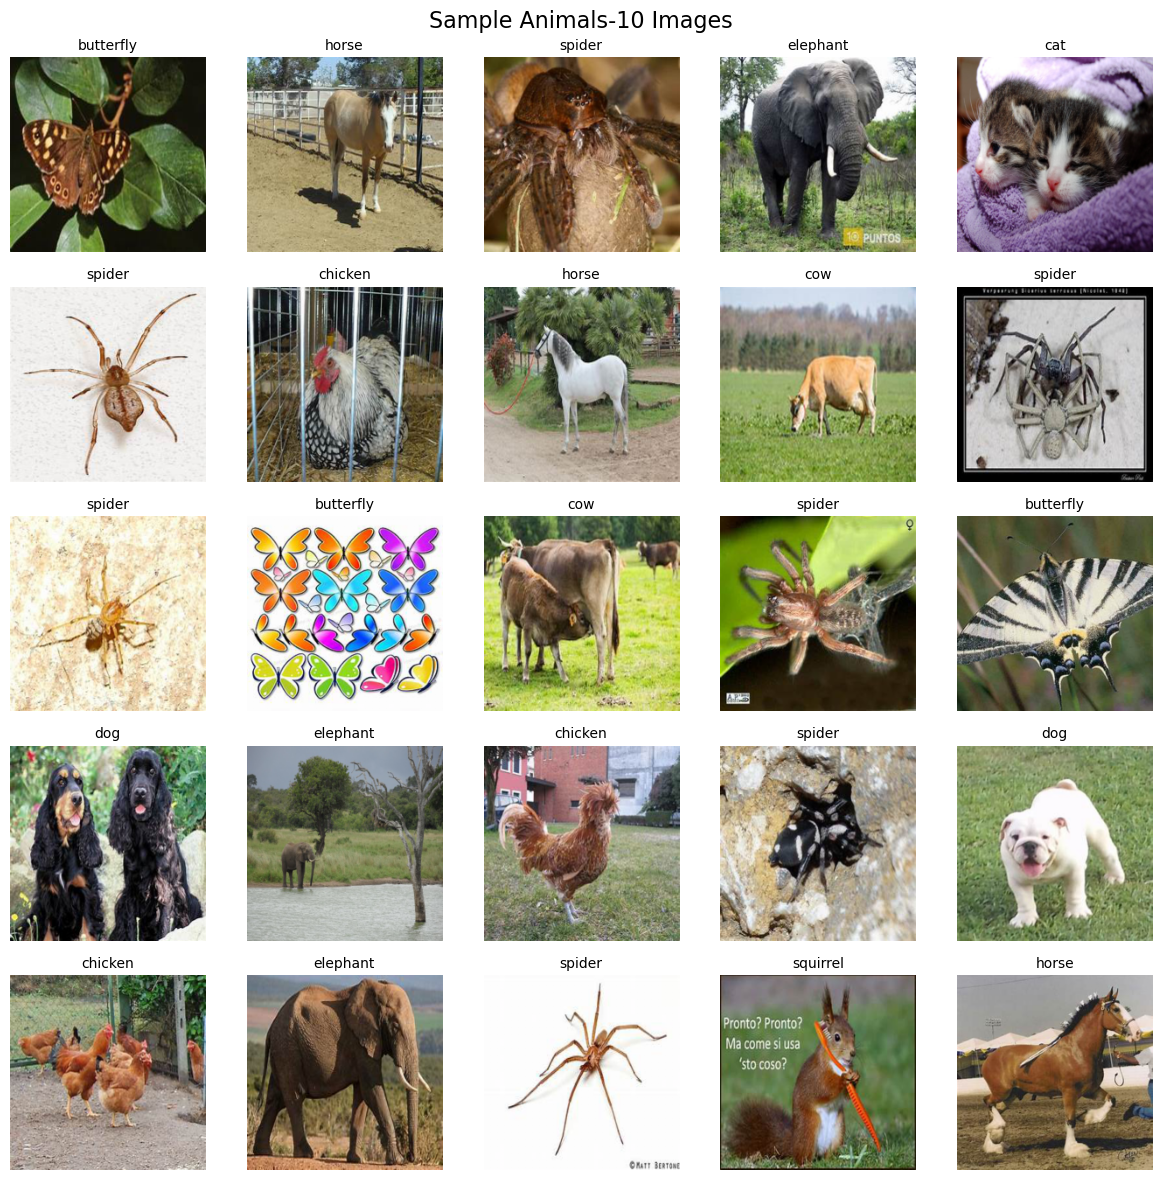

✓ Visualization saved to ../outputs/samples.png


In [5]:
# Visualize sample images
data_loader.visualize_samples(
    train_loader.dataset, 
    num_samples=25,
    save_path='../outputs/samples.png'
)

Full Dataset Class Distribution:
    Class  Count
      dog   4863
    horse   2623
 elephant   1446
butterfly   2112
  chicken   3098
      cat   1668
      cow   1866
    sheep   1820
   spider   4821
 squirrel   1862


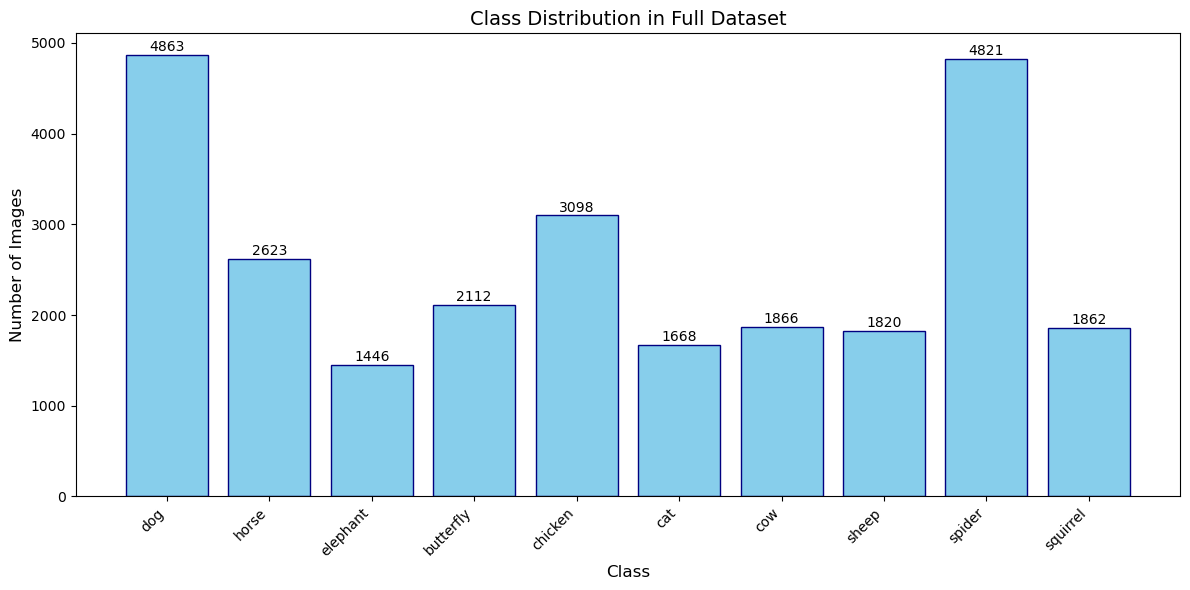

In [6]:
# Class distribution from full dataset
full_dataset = train_loader.dataset.dataset
distribution = full_dataset.get_class_distribution()

df = pd.DataFrame({
    'Class': list(distribution.keys()),
    'Count': list(distribution.values())
})

print("Full Dataset Class Distribution:")
print(df.to_string(index=False))

plt.figure(figsize=(12, 6))
bars = plt.bar(df['Class'], df['Count'], color='skyblue', edgecolor='navy')
plt.title('Class Distribution in Full Dataset', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar, count in zip(bars, df['Count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150)
plt.show()

In [7]:
# Verify stratified splits - show class distribution per split
print("="*60)
print("VERIFYING STRATIFIED SPLITS")
print("="*60)

full_labels = full_dataset.get_labels()

for split_name, loader in [("Training", train_loader), 
                           ("Validation", val_loader), 
                           ("Test", test_loader)]:
    
    # Get labels from this split
    if hasattr(loader.dataset, 'indices'):
        split_labels = [full_labels[idx] for idx in loader.dataset.indices]
    else:
        split_labels = [full_labels[idx] for idx, _ in loader.dataset]
    
    unique, counts = np.unique(split_labels, return_counts=True)
    
    print(f"\n{split_name} Split:")
    print(f"  Total images: {len(split_labels)}")
    for class_idx, count in zip(unique, counts):
        class_name = data_loader.classes[class_idx]
        percentage = (count / len(split_labels)) * 100
        print(f"    {class_name}: {count} ({percentage:.1f}%)")

VERIFYING STRATIFIED SPLITS

Training Split:
  Total images: 18322
    dog: 3404 (18.6%)
    horse: 1836 (10.0%)
    elephant: 1012 (5.5%)
    butterfly: 1478 (8.1%)
    chicken: 2168 (11.8%)
    cat: 1167 (6.4%)
    cow: 1306 (7.1%)
    sheep: 1274 (7.0%)
    spider: 3374 (18.4%)
    squirrel: 1303 (7.1%)

Validation Split:
  Total images: 3922
    dog: 729 (18.6%)
    horse: 393 (10.0%)
    elephant: 216 (5.5%)
    butterfly: 316 (8.1%)
    chicken: 464 (11.8%)
    cat: 250 (6.4%)
    cow: 279 (7.1%)
    sheep: 273 (7.0%)
    spider: 723 (18.4%)
    squirrel: 279 (7.1%)

Test Split:
  Total images: 3935
    dog: 730 (18.6%)
    horse: 394 (10.0%)
    elephant: 218 (5.5%)
    butterfly: 318 (8.1%)
    chicken: 466 (11.8%)
    cat: 251 (6.4%)
    cow: 281 (7.1%)
    sheep: 273 (6.9%)
    spider: 724 (18.4%)
    squirrel: 280 (7.1%)


In [8]:
# Image statistics from a batch
images, labels = next(iter(train_loader))

print("="*60)
print("IMAGE STATISTICS")
print("="*60)
print(f"\nBatch Information:")
print(f"  Batch shape: {images.shape}")
print(f"  Labels shape: {labels.shape}")

print(f"\nPixel Statistics (after normalization):")
print(f"  Mean: {images.mean():.4f}")
print(f"  Std: {images.std():.4f}")
print(f"  Min: {images.min():.4f}")
print(f"  Max: {images.max():.4f}")

# Check for data issues
print(f"\nData Quality Checks:")
print(f"  Contains NaN: {torch.isnan(images).any()}")
print(f"  Contains Inf: {torch.isinf(images).any()}")
print(f"  Unique labels in batch: {torch.unique(labels).tolist()}")

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


IMAGE STATISTICS

Batch Information:
  Batch shape: torch.Size([64, 3, 224, 224])
  Labels shape: torch.Size([64])

Pixel Statistics (after normalization):
  Mean: 0.1357
  Std: 1.1667
  Min: -2.1179
  Max: 2.6400

Data Quality Checks:
  Contains NaN: False
  Contains Inf: False
  Unique labels in batch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [9]:
# Summary
print("="*60)
print("DATA EXPLORATION SUMMARY")
print("="*60)

print(f"\n📊 Dataset Overview:")
print(f"  Total images: {len(full_dataset)}")
print(f"  Number of classes: {len(data_loader.classes)}")
print(f"  Class names: {', '.join(data_loader.classes)}")

print(f"\n📂 Data Split:")
print(f"  Training: {len(train_loader.dataset)} images ({len(train_loader)} batches)")
print(f"  Validation: {len(val_loader.dataset)} images ({len(val_loader)} batches)")
print(f"  Test: {len(test_loader.dataset)} images ({len(test_loader)} batches)")

print(f"\n🖼️ Image Properties:")
print(f"  Size: {data_loader.image_size}x{data_loader.image_size} pixels")
print(f"  Channels: 3 (RGB)")
print(f"  Normalization: ImageNet mean/std (0.485, 0.456, 0.406)")

print(f"\n✅ Data exploration complete! Ready for model building.")

DATA EXPLORATION SUMMARY

📊 Dataset Overview:
  Total images: 26179
  Number of classes: 10
  Class names: dog, horse, elephant, butterfly, chicken, cat, cow, sheep, spider, squirrel

📂 Data Split:
  Training: 18322 images (287 batches)
  Validation: 3922 images (62 batches)
  Test: 3935 images (62 batches)

🖼️ Image Properties:
  Size: 224x224 pixels
  Channels: 3 (RGB)
  Normalization: ImageNet mean/std (0.485, 0.456, 0.406)

✅ Data exploration complete! Ready for model building.
